In [1]:
!pip install feature-engine
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.5 MB/s eta 0:00:00


In [19]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn import set_config
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin

from itertools import combinations
from scipy.stats import pointbiserialr

pd.set_option('display.max_columns', None)
set_config(transform_output='pandas')

In [3]:
ROOT = "/content/drive/MyDrive/ml-project"
FILE = "smart-contract-dataset.csv"
SEED = 78

In [4]:
data = pd.read_csv(os.path.join(ROOT, "data", FILE))

In [5]:
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt')
        .replace('>', 'gt')
        .replace('__', '_double_underscore')
        .replace(':', '_colon')
    )
)

In [6]:
X = data.iloc[:, 3:].select_dtypes(include="number")
y = data.label

In [7]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED
)

print(X_train.shape, X_val.shape, X_test.shape)

(23468, 263) (5868, 263) (7335, 263)


In [18]:
class TreeFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=15, random_state=42):
        self.k = k
        self.random_state = random_state

    def fit(self, X, y):
        self.feature_names_in_ = X.columns
        self.tree_ = DecisionTreeClassifier(random_state=self.random_state)
        self.tree_.fit(X, y)
        importances = self.tree_.feature_importances_
        indices = np.argsort(importances)[::-1][:self.k]
        self.selected_features_ = self.feature_names_in_[indices]

        return self

    def transform(self, X):

        return X[self.selected_features_]


class SelectiveInteraction(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold
        self.interactions_ = []

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).copy()

        if not set(np.unique(y)).issubset({0, 1}):
            raise ValueError("Target `y` must be binary (0/1) for point-biserial correlation.")

        self.feature_corr_ = {
            col: pointbiserialr(X[col], y)[0]
            for col in X.columns
        }
        self.interactions_ = [
            (f1, f2)
            for f1, f2 in combinations(X.columns, 2)
            if abs(self.feature_corr_[f1]) >= self.threshold
            and abs(self.feature_corr_[f2]) >= self.threshold
            and np.sign(self.feature_corr_[f1]) != np.sign(self.feature_corr_[f2])
        ]

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        new_features = {
            f"{f1}_x_{f2}": X[f1] * X[f2]
            for f1, f2 in self.interactions_
        }
        X_new = pd.concat([X, pd.DataFrame(new_features, index=X.index)], axis=1)

        return X_new


def print_cv_results(cv_results):
    for key, values in cv_results.items():
        if key.startswith("test_"):
            metric = key.replace("test_", "").capitalize()
            mean = np.mean(values)
            std = np.std(values)
            print(f"{metric} Mean: {mean:.4f} | Std: {std:.4f}")


### Random Forest

In [9]:
random_forest_hyperparameters = {
    'n_estimators': 100,
    'criterion': 'gini',
    'max_depth': 10,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': True,
    'class_weight': 'balanced',
    'random_state': SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)

random_forest_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", RandomForestClassifier(
                **random_forest_hyperparameters
            )
        )
    ]
)

### XGBoost

In [10]:
xgboost_hyperparameters = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": 3,
    "learning_rate": 0.05,
    "max_depth":6,
    "min_child_weight": 1,
    "gamma": 0.2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "n_estimators": 500,
    "verbosity": 1,
    "random_state": SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


xgboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", XGBClassifier(
                **xgboost_hyperparameters
            )
        )
    ]
)

### LightGBM

In [11]:
lightgbm_hyperparameters = {
    "objective": "binary",
    "metric": "aucpr",
    "is_unbalance": True,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "min_child_weight": 1e-3,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "n_estimators": 500,
    "verbosity": -1,
    "random_state": SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


lightgbm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)

### CatBoost

In [12]:
catboost_hyperparaters = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3,
    "random_strength": 1.5,
    "bagging_temperature": 1.0,
    "border_count": 128,
    "loss_function": "Logloss",
    "eval_metric": "F1",
    "scale_pos_weight": 3,
    "verbose": 0,
    "task_type": "CPU",
    "random_seed": SEED
}


feature_selection_steps = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelection", TreeFeatureSelector(k=50)
        )
    ]
)


preprocessing_pipeline = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)


catboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline
        ),
        (
            "Classifier", CatBoostClassifier(
                **catboost_hyperparaters
            )
        )
    ]
)

### Voting Classifier

In [17]:
voting_classifier = VotingClassifier(
    estimators=[
        ('random_forest', random_forest_pipeline),
        ('xgboost', xgboost_pipeline),
        ('lightgbm', lightgbm_pipeline),
        ('catboost', catboost_pipeline)
    ],
    voting='soft',
)

In [20]:
voting_clf_cv_results = cross_validate(
    voting_classifier,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
)


In [21]:
print_cv_results(voting_clf_cv_results)

Accuracy Mean: 0.7519 | Std: 0.0068
Precision Mean: 0.5273 | Std: 0.0100
Recall Mean: 0.6825 | Std: 0.0113
F1 Mean: 0.5949 | Std: 0.0101
Roc_auc Mean: 0.8123 | Std: 0.0048
Average_precision Mean: 0.6392 | Std: 0.0065


In [22]:
voting_classifier.fit(X_train_val, y_train_val)
y_pred = voting_classifier.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      5410
           1       0.53      0.70      0.60      1925

    accuracy                           0.76      7335
   macro avg       0.70      0.74      0.71      7335
weighted avg       0.79      0.76      0.77      7335



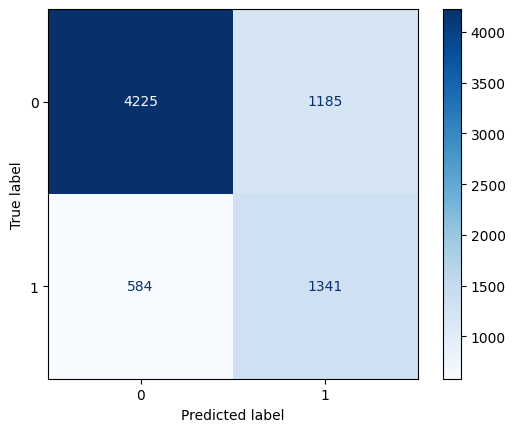

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues');

### Stacking Classifier

In [27]:
import warnings
warnings.filterwarnings("ignore", message="X has feature names")

In [25]:
stacking_classifier = StackingClassifier(
    estimators=[
        ('random_forest', random_forest_pipeline),
        ('xgboost', xgboost_pipeline),
        ('lightgbm', lightgbm_pipeline),
        ('catboost', catboost_pipeline)
    ],
    final_estimator=LogisticRegression(random_state=SEED),
    cv=5
)

stacking_clf_cv_results = cross_validate(
    stacking_classifier,
    X_train_val,
    y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has fe

In [26]:
print_cv_results(stacking_clf_cv_results)

Accuracy Mean: 0.7946 | Std: 0.0034
Precision Mean: 0.6677 | Std: 0.0100
Recall Mean: 0.4592 | Std: 0.0078
F1 Mean: 0.5441 | Std: 0.0077
Roc_auc Mean: 0.8124 | Std: 0.0056
Average_precision Mean: 0.6385 | Std: 0.0074


In [28]:
stacking_classifier.fit(X_train_val, y_train_val)
y_pred = stacking_classifier.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      5410
           1       0.68      0.47      0.56      1925

    accuracy                           0.80      7335
   macro avg       0.75      0.70      0.72      7335
weighted avg       0.79      0.80      0.79      7335



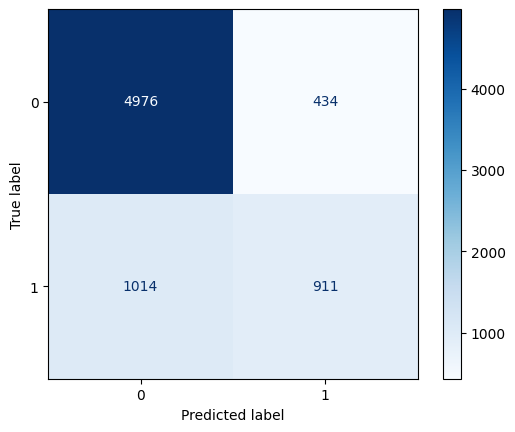

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues');